In [92]:
#Installing the libraries
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib
!pip install sklearn.cluster
!pip install sklearn.preprocessing

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
ERROR: Could not find a version that satisfies the requirement sklearn.cluster (from versions: none)
ERROR: No matching distribution found for sklearn.cluster
Defaulting to user installation because normal site-packages is not writeable
ERROR: Could not find a version that satisfies the requirement sklearn.preprocessing (from versions: none)
ERROR: No matching distribution found for sklearn.preprocessing


In [93]:
#Reading in DataFrames and Cleaning Data
df_greenspace = pd.read_csv('shared_data_read_only/Greenspace.csv')
df_walkability = pd.read_csv('shared_data_read_only/Walkability.csv')
df_rentdata = pd.read_csv('shared_data_read_only/HUD_Rent_Data.csv')
df_econ = pd.read_csv('shared_data_read_only/2021_CBP_NAICS_ECON_DATA.csv')
df_school_valueadded = pd.read_excel('shared_data_read_only/District_Value_Added_Ranking.xlsx')

In [94]:
df_rent_prop = pd.read_excel('Team-13/rent_data_feature_proportions.xlsx')

In [95]:
df_school_variance = pd.read_excel('Team-13/Education Variance Per Zip Code.xlsx')

In [96]:
df_school_variance['Zip Code'] = df_school_variance['Zip Code'].astype(str)

In [97]:
df_rent_prop['Unnamed: 0'] = df_rent_prop['Unnamed: 0'].astype(str)

In [98]:
df_zip = pd.read_csv('shared_data_read_only/geography_mappings/ZIP_TRACT_122021.csv')

In [99]:
df_econ = pd.read_csv('shared_data_read_only/2021_CBP_NAICS_ECON_DATA.csv')

In [100]:
df_econ = df_econ[['ZIP_CODE', 'NAICS2017_LABEL']]

In [101]:
df2 = df_econ.copy() 
df2 = df2.groupby(['ZIP_CODE']).count()
df2 = df2.sort_values('NAICS2017_LABEL', ascending = True)
df2 = df2.rename(columns={'NAICS2017_LABEL': "Total Establishments"})
df2

,Total Establishments
ZIP_CODE,
45218,1
45623,1
44629,1
44628,1
45657,1
...,...
44122,340
45069,355
45202,360


In [102]:
#medical services (physical health) 
df3 = df_econ.copy() 
filter1 = df3['NAICS2017_LABEL'] == 'Offices of physicians (except mental health specialists)'
filter2 = df3['NAICS2017_LABEL'] == 'Offices of dentists'
filter3 = df3['NAICS2017_LABEL'] == 'Offices of chiropractors'
filter4 = df3['NAICS2017_LABEL'] == 'Offices of physical, occupational and speech therapists, and audiologists'
df3 = df3.where(filter1 | filter2 | filter3 | filter4)
df3 = df3.dropna()
df3 = df3.groupby(['ZIP_CODE']).count()
df3 = df3.sort_values('NAICS2017_LABEL', ascending = True)
df3 = df3.rename(columns={'NAICS2017_LABEL': 'Medical Service Establishments'})
df_econ_column = df3.copy()

In [103]:
df_econ_column.head()

,Medical Service Establishments
ZIP_CODE,
43793.0,1
44040.0,1
44137.0,1
43515.0,1
44273.0,1


In [104]:
df_greenspace.head()

,Census_Block_Group,Greenspace_Pct,Greenspace_Per_Cap
0,484530001011,78.599998,893.59
1,484530001012,67.169998,587.18
2,484530001013,61.180000,433.15
3,484530001021,82.650002,1385.59
4,484530001022,74.889999,2273.05


In [105]:
df_greenspace.dtypes

Census_Block_Group      int64
Greenspace_Pct        float64
Greenspace_Per_Cap    float64
dtype: object

In [106]:
#Creating column for Census Tract
df_greenspace['Census_Block_Group'] = df_greenspace['Census_Block_Group'].astype(str)
df_greenspace['Tract'] = df_greenspace['Census_Block_Group'].str[5:-1]

In [107]:
df_walkability.head()

,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,CBSA,CBSA_Name,NatWalkInd
0,48,113,7825,4,19100.0,"Dallas-Fort Worth-Arlington, TX",14.000000
1,48,113,7825,2,19100.0,"Dallas-Fort Worth-Arlington, TX",10.833333
2,48,113,7825,3,19100.0,"Dallas-Fort Worth-Arlington, TX",8.333333
3,48,113,7824,1,19100.0,"Dallas-Fort Worth-Arlington, TX",15.666667
4,48,113,7824,2,19100.0,"Dallas-Fort Worth-Arlington, TX",10.166667


In [108]:
#Filling in Tract column with leading zeroes
df_walkability['TRACTCE'] = df_walkability['TRACTCE'].astype(str).str.zfill(6)

In [109]:
#Combining Walkability and Greenspace Columns
greenspace_and_walkability = df_walkability.merge(df_greenspace, left_on='TRACTCE', right_on='Tract', how='inner')

In [110]:
greenspace_and_walkability.head()

,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,CBSA,CBSA_Name,NatWalkInd,Census_Block_Group,Greenspace_Pct,Greenspace_Per_Cap,Tract
0,48,113,009301,2,19100.0,"Dallas-Fort Worth-Arlington, TX",8.0,410510093011,57.000000,226.40,009301
1,48,113,009301,2,19100.0,"Dallas-Fort Worth-Arlington, TX",8.0,410510093012,56.970001,177.55,009301
2,48,113,009301,2,19100.0,"Dallas-Fort Worth-Arlington, TX",8.0,410510093013,43.259998,71.04,009301
3,48,113,009301,2,19100.0,"Dallas-Fort Worth-Arlington, TX",8.0,110010093011,54.189999,171.00,009301
4,48,113,009301,2,19100.0,"Dallas-Fort Worth-Arlington, TX",8.0,110010093012,43.330002,151.00,009301


In [111]:
#Filtering for Ohio
greenspace_and_walkability = greenspace_and_walkability.loc[greenspace_and_walkability['STATEFP'] == 39]

In [112]:
greenspace_and_walkability['CITY'] = greenspace_and_walkability['CBSA_Name'].str.split(',').str[0]

In [113]:
# Calculate the mean 'NatWalkInd' for each 'CITY'
city_walkability_mean = greenspace_and_walkability.groupby('CITY')['NatWalkInd'].mean().reset_index()

# Merge the calculated means back into the original DataFrame based on 'CITY'
greenspace_and_walkability = greenspace_and_walkability.merge(city_walkability_mean, on='CITY', suffixes=('', '_mean'))

# Rename the new column to a meaningful name
greenspace_and_walkability.rename(columns={'NatWalkInd_mean': 'Mean_NatWalkInd'}, inplace=True)

In [114]:
# Calculate the mean 'NatWalkInd' for each 'CITY'
city_greenspace_mean = greenspace_and_walkability.groupby('CITY')['Greenspace_Pct'].mean().reset_index()

# Merge the calculated means back into the original DataFrame based on 'CITY'
greenspace_and_walkability = greenspace_and_walkability.merge(city_greenspace_mean, on='CITY', suffixes=('', '_mean'))


In [115]:
#Mapping the disparity metrics onto the appropriate cities
greenspace_and_walkability['Greenspace'] = greenspace_and_walkability['CITY'].map(city_walkability_mean['NatWalkInd'])

In [116]:
greenspace_and_walkability.tail()

,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,CBSA,CBSA_Name,NatWalkInd,Census_Block_Group,Greenspace_Pct,Greenspace_Per_Cap,Tract,CITY,Mean_NatWalkInd,Greenspace_Pct_mean,Greenspace
76670,39,99,801600,5,49660.0,"Youngstown-Warren-Boardman, OH-PA",11.0,240338016002,43.430000,93.0,801600,Youngstown-Warren-Boardman,6.609559,54.673966,NaN
76671,39,99,801600,5,49660.0,"Youngstown-Warren-Boardman, OH-PA",11.0,240338016003,55.639999,103.0,801600,Youngstown-Warren-Boardman,6.609559,54.673966,NaN
76672,39,99,801600,2,49660.0,"Youngstown-Warren-Boardman, OH-PA",6.0,240338016001,69.769997,131.0,801600,Youngstown-Warren-Boardman,6.609559,54.673966,NaN
76673,39,99,801600,2,49660.0,"Youngstown-Warren-Boardman, OH-PA",6.0,240338016002,43.430000,93.0,801600,Youngstown-Warren-Boardman,6.609559,54.673966,NaN
76674,39,99,801600,2,49660.0,"Youngstown-Warren-Boardman, OH-PA",6.0,240338016003,55.639999,103.0,801600,Youngstown-Warren-Boardman,6.609559,54.673966,NaN


In [118]:
df_zip['tract'] = df_zip['tract'].astype(str)
df_zip['Tract'] = df_zip['tract'].str[5:]

In [119]:
df_econ_column = df_econ_column.reset_index(drop=False)
df_econ_column.dtypes

ZIP_CODE                          float64
Medical Service Establishments      int64
dtype: object

In [120]:
df_econ_column['ZIP_CODE'] = df_econ_column['ZIP_CODE'].astype(str).str[:-2]

In [121]:
df_zip['zip'] = df_zip['zip'].astype(str)

In [122]:
df_zip.head()

,zip,tract,usps_zip_pref_city,usps_zip_pref_state,res_ratio,bus_ratio,oth_ratio,tot_ratio,Tract
0,683,72023830102,SAN GERMAN,PR,0.000791,0.001116,0.000000,0.000800,830102
1,683,72125840700,SAN GERMAN,PR,0.186219,0.370536,0.381643,0.201179,840700
2,683,72125840400,SAN GERMAN,PR,0.300451,0.187500,0.115942,0.290308,840400
3,683,72125840600,SAN GERMAN,PR,0.095325,0.007812,0.000000,0.088184,840600
4,683,72121960300,SAN GERMAN,PR,0.042402,0.002232,0.019324,0.039435,960300


In [123]:
greenspace_and_walkability.shape

(76675, 15)

In [124]:
#Complete DataFrame with all metrics
merged_econ_walk = df_econ_column.merge(df_zip, left_on='ZIP_CODE', right_on='zip', how='inner')
final_matched_df = merged_econ_walk.merge(greenspace_and_walkability, on='Tract', how='inner')

In [125]:
final_matched_df.drop_duplicates(inplace=True)

In [126]:
final_matched_df['Mean_NatWalkInd'].unique()

array([10.76492907, 11.12807661, 10.63802019, 10.81684922,  6.09505941,
        9.14766607, 11.96670122,  6.56697557,  6.22519252,  7.16991057,
        6.55352703,  5.89150867,  7.1689038 ,  6.8046859 ,  5.90620783,
        6.44891735,  5.97532781,  6.78677083,  6.71328725,  5.9533086 ,
        7.6372847 ,  5.7137823 ,  5.99395004,  6.60955928,  6.45244003,
        7.68767908,  7.46453333,  4.08928571])

In [127]:
final_matched_df.tail()

,ZIP_CODE,Medical Service Establishments,zip,tract,usps_zip_pref_city,usps_zip_pref_state,res_ratio,bus_ratio,oth_ratio,tot_ratio,...,CBSA,CBSA_Name,NatWalkInd,Census_Block_Group,Greenspace_Pct,Greenspace_Per_Cap,CITY,Mean_NatWalkInd,Greenspace_Pct_mean,Greenspace
465198,45069,18,45069,39017011109,WEST CHESTER,OH,0.095904,0.200075,0.107034,0.107196,...,17140.0,"Cincinnati, OH-KY-IN",9.166667,120570111092,88.173739,1286.303200,Cincinnati,11.128077,41.775884,NaN
465199,45069,18,45069,39017011109,WEST CHESTER,OH,0.095904,0.200075,0.107034,0.107196,...,17140.0,"Cincinnati, OH-KY-IN",8.500000,120570111091,87.656959,3976.359285,Cincinnati,11.128077,41.775884,NaN
465200,45069,18,45069,39017011109,WEST CHESTER,OH,0.095904,0.200075,0.107034,0.107196,...,17140.0,"Cincinnati, OH-KY-IN",8.500000,120570111092,88.173739,1286.303200,Cincinnati,11.128077,41.775884,NaN
465201,45069,18,45069,39017011109,WEST CHESTER,OH,0.095904,0.200075,0.107034,0.107196,...,17140.0,"Cincinnati, OH-KY-IN",4.666667,120570111091,87.656959,3976.359285,Cincinnati,11.128077,41.775884,NaN
465202,45069,18,45069,39017011109,WEST CHESTER,OH,0.095904,0.200075,0.107034,0.107196,...,17140.0,"Cincinnati, OH-KY-IN",4.666667,120570111092,88.173739,1286.303200,Cincinnati,11.128077,41.775884,NaN


In [128]:
# Calculate the mean 'bus_ratio' for each 'CITY'
city_bus_ratio_mean = final_matched_df.groupby('CITY')['bus_ratio'].mean().reset_index()

# Merge the calculated means back into the original DataFrame based on 'CITY'
final_matched_df = final_matched_df.merge(city_bus_ratio_mean, on='CITY', suffixes=('', '_mean'))

In [129]:
final_matched_df_2 = final_matched_df.merge(df_rent_prop, left_on='zip', right_on='Unnamed: 0')

In [130]:
final_matched_df_2 = final_matched_df_2.merge(df_school_variance, left_on='zip', right_on='Zip Code')

In [131]:
final_matched_df_2['Variance'].unique()

array([ 473.4650621 ,  117.02916601,  242.06856625,  160.39762671,
        150.19967477,  378.99716254,  428.24290845,  279.43358733,
        101.38949749,  270.48536255, 1000.        ,  217.67541823,
        199.92364993,  150.36476841,  375.82275583,   84.60027968,
         93.91749864,  180.36214362,  180.04387317,   52.47639713,
         71.78253934,  326.64953803])

In [ ]:
#Making Similarity to Columbus Column
final_matched_df_2.loc[final_matched_df_2['CITY'] == 'Columbus']

# Select the metrics for similarity calculation
selected_metrics = ['Mean_NatWalkInd', 'Greenspace_Pct_mean', 'Medical Service Establishments',
                    'Proportion', 'Variance']

# Calculate the average difference for each city compared to 'Columbus'
final_matched_df_2['Avg_Diff'] = final_matched_df_2.apply(lambda row: row[selected_metrics].sub(final_matched_df_2[final_matched_df_2['CITY'] == 'Columbus'][selected_metrics].values[0]).abs().mean(), axis=1)

# Calculate similarity scores (inverse of average difference)
final_matched_df_2['Similarity_Score'] = 1 / (1 + final_matched_df_2['Avg_Diff'])

# Normalize similarity scores to obtain percent similarity
final_matched_df_2['Percent_Similarity'] = (final_matched_df_2['Similarity_Score'] / final_matched_df_2['Similarity_Score'].sum()) * 100

In [40]:
final_matched_df_2.drop_duplicates(inplace=True)

In [41]:
final_matched_df_2.head()

,ZIP_CODE,Medical Service Establishments,zip,tract,usps_zip_pref_city,usps_zip_pref_state,res_ratio,bus_ratio,oth_ratio,tot_ratio,...,Greenspace_Pct_mean,Greenspace,bus_ratio_mean,Unnamed: 0,0,1,Proportion,Zip Code,County,Variance
0,44040,1,44040,39035196300,GATES MILLS,OH,0.011923,0.016807,0.0,0.012155,...,51.924554,NaN,0.079683,44040,0,1,0,44040,Cuyahoga,473.465062
1,44040,1,44040,39035196300,GATES MILLS,OH,0.011923,0.016807,0.0,0.012155,...,51.924554,NaN,0.079683,44040,0,1,0,44040,Cuyahoga,473.465062
2,44040,1,44040,39035196300,GATES MILLS,OH,0.011923,0.016807,0.0,0.012155,...,51.924554,NaN,0.079683,44040,0,1,0,44040,Cuyahoga,473.465062
3,44040,1,44040,39035196300,GATES MILLS,OH,0.011923,0.016807,0.0,0.012155,...,51.924554,NaN,0.079683,44040,0,1,0,44040,Cuyahoga,473.465062
4,44040,1,44040,39035196300,GATES MILLS,OH,0.011923,0.016807,0.0,0.012155,...,51.924554,NaN,0.079683,44040,0,1,0,44040,Cuyahoga,473.465062


In [63]:
df_grouped = final_matched_df_2.groupby('CITY').mean()

In [64]:
df_grouped

,Medical Service Establishments,res_ratio,bus_ratio,oth_ratio,tot_ratio,STATEFP,COUNTYFP,BLKGRPCE,CBSA,NatWalkInd,...,Greenspace_Per_Cap,Mean_NatWalkInd,Greenspace_Pct_mean,Greenspace,bus_ratio_mean,0,1,Proportion,Variance,Cluster
CITY,,,,,,,,,,,,,,,,,,,,,
Akron,6.415718,0.130658,0.117712,0.128907,0.129508,39.0,146.075171,2.351936,10420.0,7.352506,...,1682.534223,7.464533,64.233546,NaN,0.121527,0.741458,1.197039,0.599089,303.441879,4.000000
Ashtabula,6.150472,0.101064,0.118636,0.117651,0.102621,39.0,7.000000,2.798815,11780.0,5.523629,...,-2669.034214,5.906208,51.099966,NaN,0.099967,0.968536,1.000000,0.968536,245.041649,1.979641
Bellefontaine,3.784000,0.069604,0.042482,0.047737,0.064296,39.0,91.000000,2.349000,13340.0,5.423167,...,-426.026005,5.975328,37.740189,NaN,0.095254,1.000000,1.000000,1.000000,512.862958,0.444000
Canton-Massillon,5.584867,0.111745,0.123661,0.120422,0.113025,39.0,123.196319,2.570552,15940.0,7.515337,...,1033.775051,7.687679,57.817650,NaN,0.123661,1.263804,1.325153,0.969325,413.146165,3.799591
Cincinnati,5.624945,0.100801,0.098819,0.107631,0.100480,39.0,47.212980,2.272606,17140.0,11.849915,...,-1388.043171,11.128077,41.775884,NaN,0.099797,0.870054,1.002020,0.868033,303.380534,1.473020
Cleveland-Elyria,6.650949,0.084762,0.084151,0.075536,0.084490,39.0,63.111645,2.146686,17460.0,10.078359,...,2868.924411,10.764929,51.924554,NaN,0.079683,0.533429,1.032390,0.521677,396.745135,3.043354
Columbus,5.801275,0.094572,0.090190,0.091641,0.093855,39.0,56.075093,2.328200,18140.0,11.204859,...,-405.068505,10.638020,41.550919,NaN,0.098938,0.846203,1.002177,0.844025,323.146885,1.675890
Dayton-Kettering,5.652541,0.092674,0.090010,0.091346,0.092575,39.0,109.872098,2.493718,19430.0,12.398824,...,-1033.325461,11.966701,45.650568,NaN,0.089009,0.862430,1.014013,0.848418,327.259361,1.589931
Findlay,6.111503,0.093065,0.083857,0.106747,0.091519,39.0,63.000000,3.029110,22300.0,7.380674,...,-2703.725660,7.169911,47.481765,NaN,0.094478,0.988920,1.000000,0.988920,260.737725,2.152498


In [65]:
# Selected metrics (dimensions) for clustering
selected_metrics = ['Mean_NatWalkInd', 'Greenspace_Pct_mean', 'Medical Service Establishments',
                    'Proportion', 'Variance']

# Create a new DataFrame with the selected metrics
X = df_grouped[selected_metrics]

# Normalize the feature matrix (if necessary)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

# Determine the number of clusters (you can specify this)
n_clusters = 7

# Create a K-Means clustering model
kmeans = KMeans(n_clusters=n_clusters, random_state=0)

# Fit the model to the data
kmeans.fit(scaled_data)

# Get cluster labels for each data point
cluster_labels = kmeans.labels_

# Add the cluster labels to the original DataFrame
df_grouped['Cluster'] = cluster_labels

# Print the resulting DataFrame with cluster labels
print(df_grouped)

                            Medical Service Establishments  res_ratio  \
CITY                                                                    
Akron                                             6.415718   0.130658   
Ashtabula                                         6.150472   0.101064   
Bellefontaine                                     3.784000   0.069604   
Canton-Massillon                                  5.584867   0.111745   
Cincinnati                                        5.624945   0.100801   
Cleveland-Elyria                                  6.650949   0.084762   
Columbus                                          5.801275   0.094572   
Dayton-Kettering                                  5.652541   0.092674   
Findlay                                           6.111503   0.093065   
Greenville                                        8.000000   0.074845   
Huntington-Ashland                                7.759124   0.078781   
Lima                                              4

In [46]:
final_matched_df_2[final_matched_df_2['Cluster'] == 0]['CITY'].unique()

array(['Cleveland-Elyria', 'Dayton-Kettering', 'Wooster', 'Springfield',
       'Cincinnati', 'Columbus', 'Toledo', 'Mansfield', 'Portsmouth',
       'Marion', 'Urbana', 'New Philadelphia-Dover', 'Marietta',
       'Van Wert', 'Weirton-Steubenville', 'Findlay', 'Ashtabula',
       'Akron', 'Canton-Massillon'], dtype=object)

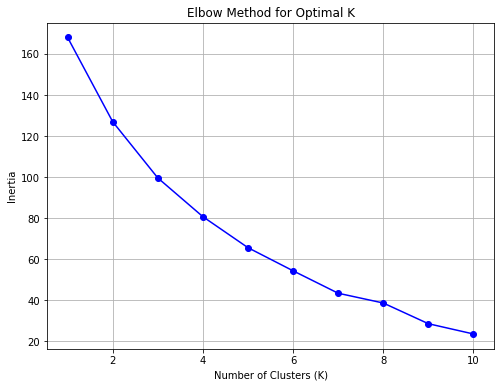

In [66]:
#Elbow Method for K-Means

# Range of cluster numbers to test
k_values = range(1, 11)
inertia_values = []

# Calculate inertia (within-cluster sum of squares) for each K
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(scaled_data)
    inertia_values.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia_values, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

In [73]:
df_grouped['Cluster'].value_counts()

1    11
0     4
4     4
3     3
2     2
5     2
6     2
Name: Cluster, dtype: int64

In [87]:
# Calculate cluster-level metrics (e.g., mean)
cluster_metrics = df_grouped.groupby('Cluster').agg({'Mean_NatWalkInd': 'mean', 'Greenspace_Pct_mean': 'mean', 'Medical Service Establishments': 'mean',
                                                          'Proportion': 'mean', 'Variance': 'mean'})

In [88]:
cluster_metrics

,Mean_NatWalkInd,Greenspace_Pct_mean,Medical Service Establishments,Proportion,Variance
Cluster,,,,,
0,11.137412,42.409253,5.683314,0.869109,324.171076
1,6.679514,46.272659,5.578981,0.951629,293.391790
2,7.621363,43.281969,5.220177,0.753837,744.643221
3,6.125851,38.259062,3.062727,0.927758,550.734084
4,6.449364,44.130799,7.606181,0.796051,400.563936
5,9.114731,58.079050,6.533334,0.560383,350.093507
6,5.349422,56.643947,9.000000,1.000000,351.236147


In [89]:
# Select only the columns containing metrics to normalize
selected_metrics = cluster_metrics.columns

# Create a StandardScaler instance
scaler = StandardScaler()

# Fit and transform the selected metrics to standardize them
cluster_metrics[selected_metrics] = scaler.fit_transform(cluster_metrics[selected_metrics])

In [90]:
cluster_metrics['Sum_Standardized_Metrics'] = cluster_metrics[selected_metrics].sum(axis=1)

In [91]:
cluster_metrics

,Mean_NatWalkInd,Greenspace_Pct_mean,Medical Service Establishments,Proportion,Variance,Sum_Standardized_Metrics
Cluster,,,,,,
0,1.960316,-0.664383,-0.237563,0.232236,-0.711508,0.579098
1,-0.440080,-0.106594,-0.297359,0.828472,-0.917101,-0.932662
2,0.067068,-0.538383,-0.503000,-0.600639,2.097079,0.522125
3,-0.738204,-1.263577,-1.739496,0.655997,0.801843,-2.283437
4,-0.564006,-0.415831,0.864487,-0.295629,-0.201234,-0.612213
5,0.871185,1.597982,0.249607,-1.998401,-0.538356,0.182018
6,-1.156279,1.390786,1.663324,1.177964,-0.530724,2.545071


In [86]:
df_grouped[df_grouped['Cluster'] == 2]

,Medical Service Establishments,res_ratio,bus_ratio,oth_ratio,tot_ratio,STATEFP,COUNTYFP,BLKGRPCE,CBSA,NatWalkInd,...,Greenspace_Per_Cap,Mean_NatWalkInd,Greenspace_Pct_mean,Greenspace,bus_ratio_mean,0,1,Proportion,Variance,Cluster
CITY,,,,,,,,,,,,,,,,,,,,,
Sandusky,5.097826,0.157106,0.182475,0.183418,0.159232,39.0,43.0,2.590909,41780.0,8.029315,...,587.741618,9.147666,46.304992,NaN,0.154043,0.762846,1.0,0.762846,755.784150,2
Wapakoneta,5.342529,0.172965,0.180875,0.209568,0.174222,39.0,11.0,2.514943,47540.0,6.127395,...,456.169321,6.095059,40.258945,NaN,0.163392,0.744828,1.0,0.744828,733.502292,2


In [178]:
# Filter the original DataFrame to include only rows with top-ranked clusters
filtered_df = final_matched_df[final_matched_df['Cluster'].isin(top_ranked_clusters.index)]

# Print the unique 'CITY' values for the filtered DataFrame
unique_cities = filtered_df['CITY'].unique()
print(unique_cities)

['Wapakoneta' 'Sandusky' 'Wooster' 'Marion' 'Findlay' 'Mansfield'
 'Portsmouth' 'Springfield' 'Weirton-Steubenville' 'Ashtabula'
 'Mount Vernon' 'Bellefontaine' 'Wheeling' 'Lima' 'Urbana'
 'New Philadelphia-Dover' 'Marietta' 'Van Wert' 'Huntington-Ashland']
